In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import kagglehub
import os

In [14]:
np.random.seed(42)

In [ ]:
# Download latest version
path = kagglehub.dataset_download("arjunbhaybhang/marine-institute-tide-prediction-dataset")

print("Path to dataset files:", path)

files_in_directory = os.listdir(path)
print("Archivos en el directorio:", files_in_directory)

# Ajustar el nombre del archivo CSV correcto
csv_file_path = os.path.join(path, 'Tide Prediction.csv')

# Cargar el dataset de poemas
data = pd.read_csv(csv_file_path)
data = data.iloc[1:]

# Mostrar las primeras filas del dataset para verificar que se haya cargado correctamente
print(data.head())

Path to dataset files: C:\Users\maria\.cache\kagglehub\datasets\arjunbhaybhang\marine-institute-tide-prediction-dataset\versions\1
Archivos en el directorio: ['Tide Prediction.csv']


C:\Users\maria\AppData\Local\Temp\ipykernel_22232\358328993.py:16: DtypeWarning: Columns (1,2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file_path)


                   time   longitude  latitude               stationID  \
1  2017-01-01T00:10:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
2  2017-01-01T00:20:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
3  2017-01-01T00:30:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
4  2017-01-01T00:40:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
5  2017-01-01T00:50:00Z  -10.101596  53.95219  Achill_Island_MODELLED   

  Water_Level Water_Level_ODM  
1        1.34           -1.23  
2         1.3           -1.27  
3        1.26           -1.31  
4        1.23           -1.34  
5        1.22           -1.35  


## Quick data cleaning

In [25]:
print(data.isna().sum())

time               0
longitude          0
latitude           0
stationID          0
Water_Level        0
Water_Level_ODM    0
dtype: int64


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6885393 entries, 1 to 6885393
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   time             object
 1   longitude        object
 2   latitude         object
 3   stationID        object
 4   Water_Level      object
 5   Water_Level_ODM  object
dtypes: object(6)
memory usage: 315.2+ MB


In [27]:
data['time'] = pd.to_datetime(data['time'])
data['longitude'] = pd.to_numeric(data['longitude'])
data['latitude'] = pd.to_numeric(data['latitude'])
data['Water_Level'] = pd.to_numeric(data['Water_Level'])
data['Water_Level_ODM'] = pd.to_numeric(data['Water_Level_ODM'])

In [28]:
data.head()

,time,longitude,latitude,stationID,Water_Level,Water_Level_ODM
1,2017-01-01 00:10:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.34,-1.23
2,2017-01-01 00:20:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.30,-1.27
3,2017-01-01 00:30:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.26,-1.31
4,2017-01-01 00:40:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.23,-1.34
5,2017-01-01 00:50:00+00:00,-10.101596,53.95219,Achill_Island_MODELLED,1.22,-1.35


In [29]:
data['stationID'].unique()

array(['Achill_Island_MODELLED', 'Aranmore', 'Arklow_MODELLED',
       'Ballycotton', 'Ballyglass', 'Bray_Harbour_MODELLED',
       'Carrigaholt_MODELLED', 'Castletownbere', 'Clare_Island_MODELLED',
       'Crosshaven_MODELLED', 'Dingle_Harbour_MODELLED', 'Dublin_Port',
       'Dundalk', 'Dungarvan_MODELLED', 'Dunmore_East', 'Fenit_MODELLED',
       'Galway_Port', 'Howth', 'Inishmore', 'Killary_Harbour_MODELLED',
       'Killybegs', 'Kinsale_MODELLED', 'Kish_Bank_Lighthouse',
       'Lahinch_MODELLED', 'Letterfrack_MODELLED', 'Malin_Head',
       'Rosslare_Port_MODELLED', 'Skerries', 'Sligo',
       'Tory_Island_MODELLED', 'Union_Hall_MODELLED', 'Wexford',
       'Wicklow_MODELLED'], dtype=object)

In [30]:
### take only data from an specific port
## lets take only from Dingle_Harbour_MODELLED

data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED']

## Data Visualization

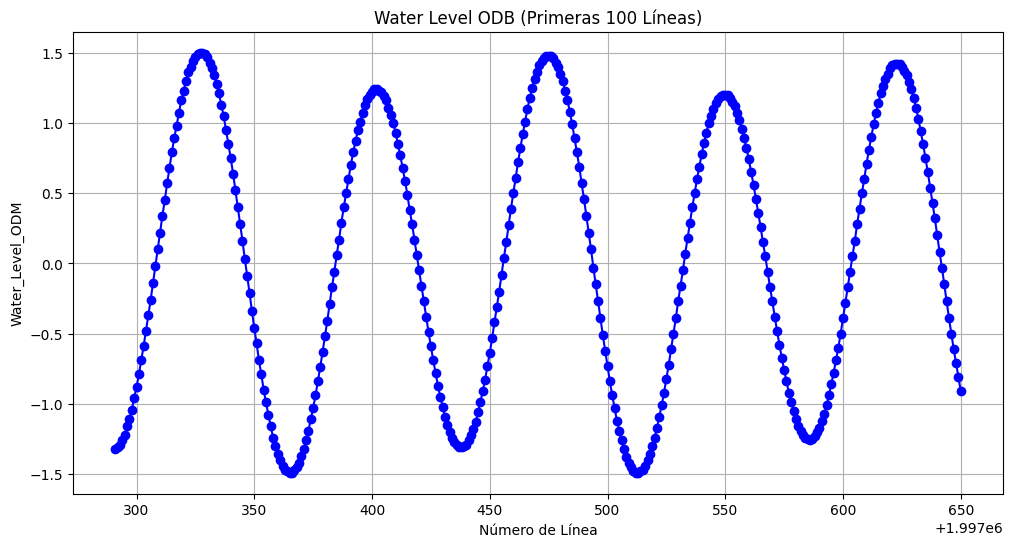

In [ ]:
primeras_100 = data_located.head(360)

##Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

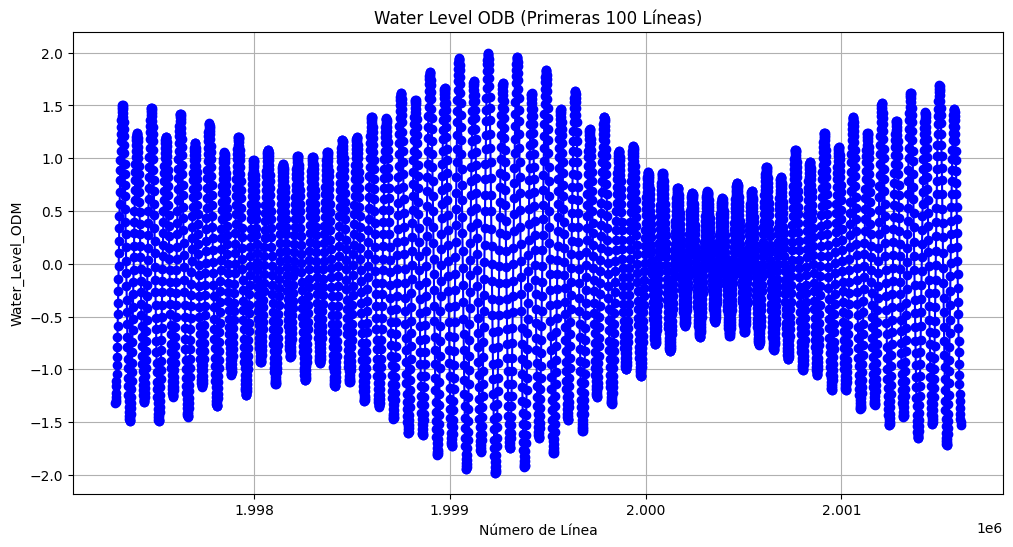

In [ ]:
primeras_100 = data_located.head(4320)

##Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 4320 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

## Detecting a random walk

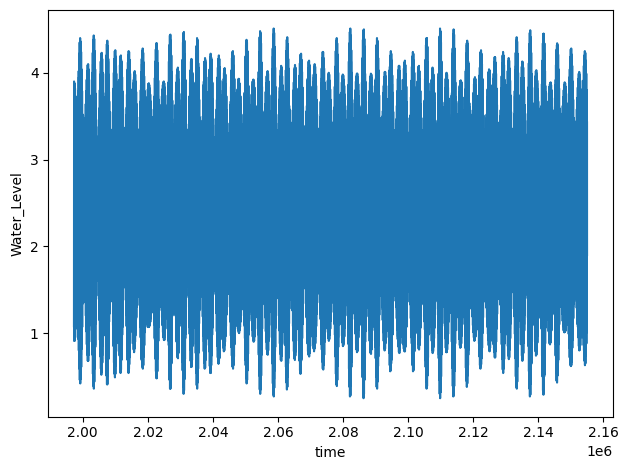

In [31]:
def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_located['Water_Level'])

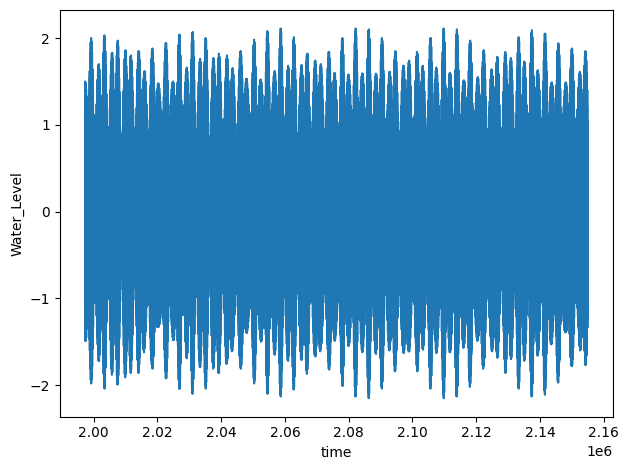

In [32]:
def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_located['Water_Level_ODM'])

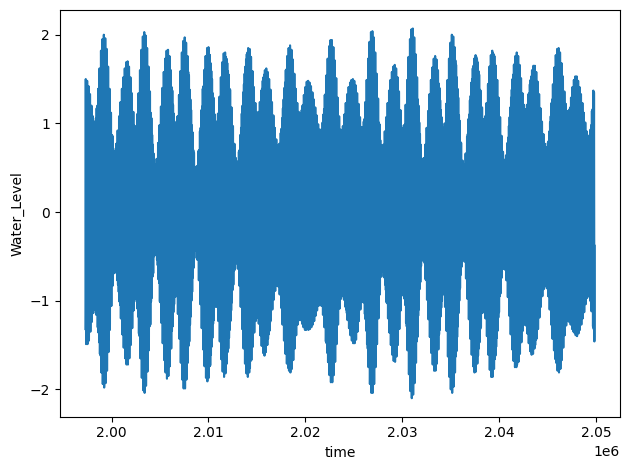

In [34]:
### Try again by taking only the 2017 data
data_2017 = data_located[data_located['time'].dt.year == 2017]

def visualize_time_series(val):
    fig, ax = plt.subplots()
    ax.plot(val)
    ax.set_xlabel('time') # Is just the sequential order
    ax.set_ylabel('Water_Level') # The randomly given value
    plt.tight_layout()

visualize_time_series(data_2017['Water_Level_ODM'])

In [35]:
from statsmodels.tsa.stattools import adfuller
ADF_result = adfuller(data_2017['Water_Level_ODM'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -30.59172717435491
p-value: 0.0


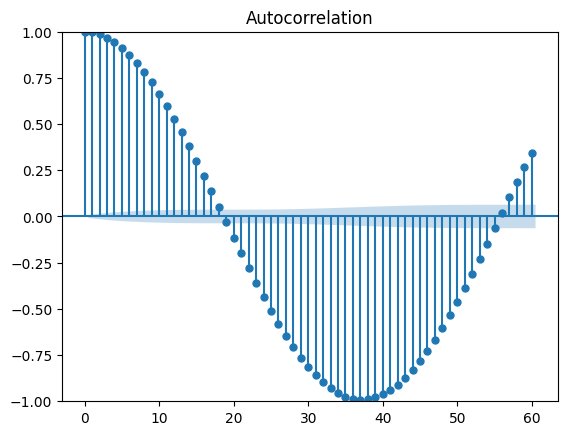

In [36]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data_2017['Water_Level_ODM'], lags=60);

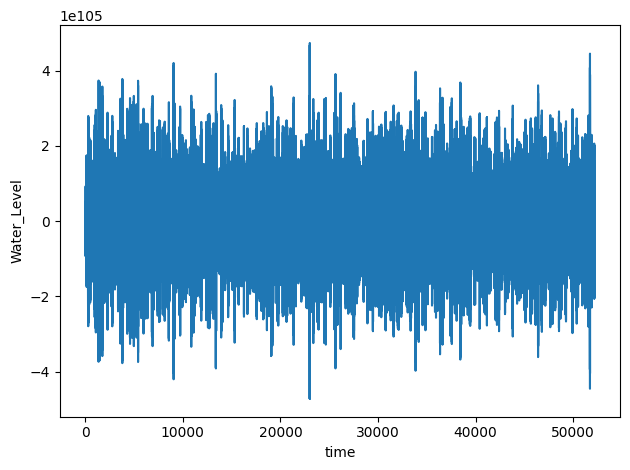

In [37]:
difference = np.diff(data_2017['Water_Level_ODM'], n=360)
visualize_time_series(difference)

ADF Statistic: -1271.771584877372
p-value: 0.0


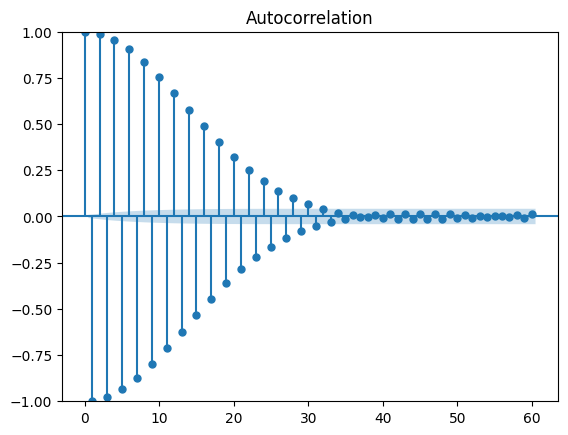

In [38]:
ADF_result = adfuller(difference)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')
plot_acf(difference, lags=60);